# Bitcoin Sentiment Analysis
This notebook performs real-time Bitcoin sentiment analysis using news data and price information.

## Setup and Dependencies

In [1]:
# # Import required libraries
# import pandas as pd
# import numpy as np
# from datetime import datetime, timedelta
# import os
# from dotenv import load_dotenv
# from textblob import TextBlob
# import statsmodels.api as sm
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
# import requests
# from newsapi import NewsApiClient
# from pycoingecko import CoinGeckoAPI

## Initialize API Clients

In [2]:
from src.common import NEWS_API_KEY, RELEVANT_SOURCES, newsapi, coingecko

2025-05-18 00:03:36 - src.common - WARNING - NEWS_API_KEY not set in environment variables
RELEVANT_SOURCES updated with categories ('pro_bitcoin',):
['fortune', 'australian-financial-review', 'business-insider', 'bloomberg', 'wirtschafts-woche']


In [3]:
from src.fetch_data import fetch_bitcoin_news, fetch_bitcoin_prices
from src.data_saver import save_data, load_data, format_sentiment_score#, get_sentiment_color 



from src.utils_analyzer import analyze_sentiment, aggregate_sentiment, prepare_time_series_data, run_forecast, compare_historical_sentiment

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

use_cached_data = True  # Set to False to fetch fresh data

# Date range
end_date = datetime.now().date()
start_date = end_date - timedelta(days=29)
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

In [5]:
# === 1. Fetch and Process News Articles ===
if use_cached_data:
    print("Loading cached news articles and sentiment data...")
    articles = load_data("articles_data.csv")
    aggregated_sentiment = load_data("aggregated_sentiment.csv")
else:
    print("Fetching Bitcoin-related news...")
    new_articles_fetch = fetch_bitcoin_news(start_date_str, end_date_str, refresh=True)
    new_articles = analyze_sentiment(new_articles_fetch)

    # Load old data and merge
    old_articles = load_data("articles_data.csv")
    if old_articles is not None:
        articles = pd.concat([old_articles, new_articles], ignore_index=True)
        # articles = articles.drop_duplicates(subset=['url'])
        
    else:
        articles = new_articles

    # Aggregate sentiment
    aggregated_sentiment = aggregate_sentiment(articles)

    # Save updated versions
    save_data(articles, "articles_data.csv")
    save_data(aggregated_sentiment, "aggregated_sentiment.csv")


Loading cached news articles and sentiment data...
2025-05-18 00:03:37 - src.common - INFO - Loaded data from data/articles_data.csv
2025-05-18 00:03:37 - src.common - INFO - Loaded data from data/aggregated_sentiment.csv


In [6]:

# === 2. Fetch and Process Bitcoin Prices ===
if use_cached_data:
    print("Loading cached Bitcoin price data...")
    price_data = load_data("price_data.csv")
else:
    print("Fetching Bitcoin price data...")
    new_prices = fetch_bitcoin_prices(start_date_str, end_date_str, refresh=True)

    # Load old data and merge
    old_prices = load_data("price_data.csv")
    if old_prices is not None:
        price_data = pd.concat([old_prices, new_prices], ignore_index=True)
        price_data = price_data.drop_duplicates(subset=['date'])
    else:
        price_data = new_prices

    save_data(price_data, "price_data.csv")

Loading cached Bitcoin price data...
2025-05-18 00:03:37 - src.common - INFO - Loaded data from data/price_data.csv


In [7]:
# === 3. Prepare Time Series ===
print("Merging sentiment and price data...")
merged_data = prepare_time_series_data(aggregated_sentiment, price_data)
# merged_data['price_diff'] = merged_data['close_price'].diff().dropna()
if merged_data is not None:
    merged_data = merged_data.drop_duplicates()
# merged_data

Merging sentiment and price data...
2025-05-18 00:03:37 - src.utils_analyzer - INFO - Preparing time series data...
2025-05-18 00:03:37 - src.utils_analyzer - INFO - Sentiment date range: 2025-04-15 00:00:00 to 2025-05-13 00:00:00
2025-05-18 00:03:37 - src.utils_analyzer - INFO - Price date range: 2025-04-15 00:00:00 to 2025-05-17 00:00:00
2025-05-18 00:03:37 - src.utils_analyzer - INFO - Time series data prepared with 14448 days.


In [8]:






# === 4. Run Forecast ===
print("Running forecast...")
forecast_results, future_forecast = run_forecast(merged_data)

# === 5. Visualization with Matplotlib / Seaborn ===
def plot_sentiment_trends(sentiment_df):
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=sentiment_df, x='date', y='avg_polarity', ax=ax)
    ax.set_title("Average Sentiment Polarity Over Time")
    ax.set_ylabel("Polarity")
    ax.set_xlabel("Date")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_price_trends(price_df):
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=price_df, x='date', y='close_price', ax=ax)
    ax.set_title("Bitcoin Close Price Over Time")
    ax.set_ylabel("Price (USD)")
    ax.set_xlabel("Date")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_price_vs_sentiment(merged_df):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=merged_df, x='avg_polarity', y='price', ax=ax)
    sns.regplot(data=merged_df, x='avg_polarity', y='price', scatter=False, ax=ax, color='red')
    ax.set_title("Bitcoin Price vs Sentiment Polarity")
    ax.set_ylabel("Price (USD)")
    ax.set_xlabel("Sentiment Polarity")
    plt.tight_layout()
    plt.show()

def plot_forecast(forecast_df):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(forecast_df['date'], forecast_df['actual_price'], label='Actual', color='blue')
    ax.plot(forecast_df['date'], forecast_df['predicted_price'], label='Forecast', linestyle='--', color='orange')
    ax.fill_between(
        forecast_df['date'],
        forecast_df['lower_ci'],
        forecast_df['upper_ci'],
        color='orange',
        alpha=0.2,
        label='95% CI'
    )
    ax.set_title("Forecast vs Actual Bitcoin Price")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_future_forecast(future_forecast):
    plt.figure(figsize=(10, 5))
    plt.plot(future_forecast['date'], future_forecast['predicted_price'], marker='o', label='Predicted Price')
    plt.title('7-Day Bitcoin Price Forecast')
    plt.xlabel('Date')
    plt.ylabel('Predicted Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Run visualizations




Running forecast...
2025-05-18 00:03:37 - src.utils_analyzer - INFO - Running time series forecasting (hourly)...
2025-05-18 00:03:37 - src.utils_analyzer - INFO - Using ARIMA parameters: (5, 2, 2)


/usr/local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2025-05-18 00:03:38 - src.utils_analyzer - INFO - Model MAPE: 2.70%
2025-05-18 00:03:38 - src.utils_analyzer - INFO - Model RMSE: 3424.56
2025-05-18 00:03:38 - src.utils_analyzer - INFO - Forecast completed successfully (hourly).


/usr/local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
future_forecast

,date,predicted_price
0,2025-05-13 01:00:00,99010.947559
1,2025-05-13 02:00:00,99144.030622
2,2025-05-13 03:00:00,99261.428849
3,2025-05-13 04:00:00,99332.440687
4,2025-05-13 05:00:00,99390.378357
...,...,...
163,2025-05-19 20:00:00,109613.996261
164,2025-05-19 21:00:00,109678.402565
165,2025-05-19 22:00:00,109742.808868
166,2025-05-19 23:00:00,109807.215171


In [10]:
forecast_results

,date,actual_price,predicted_price,avg_polarity,upper_ci,lower_ci,mape,rmse
0,2025-05-09,103117.036231,100647.382207,0.225000,107359.518456,93935.245957,2.702043,3424.559311
1,2025-05-09,103209.383643,100780.465270,0.225000,107492.601519,94068.329020,2.702043,3424.559311
2,2025-05-09,102977.496819,100897.863497,0.225000,107609.999747,94185.727247,2.702043,3424.559311
3,2025-05-09,102827.526540,100968.875335,0.225000,107681.011585,94256.739086,2.702043,3424.559311
4,2025-05-09,103775.851994,101026.813005,0.225000,107738.949255,94314.676755,2.702043,3424.559311
...,...,...,...,...,...,...,...,...
163,2025-05-13,102341.369391,109613.996261,0.188819,116326.132511,102901.860012,2.702043,3424.559311
164,2025-05-13,102822.916795,109678.402565,0.188819,116390.538814,102966.266315,2.702043,3424.559311
165,2025-05-13,104328.029840,109742.808868,0.188819,116454.945117,103030.672618,2.702043,3424.559311
166,2025-05-13,103476.256862,109807.215171,0.188819,116519.351421,103095.078921,2.702043,3424.559311


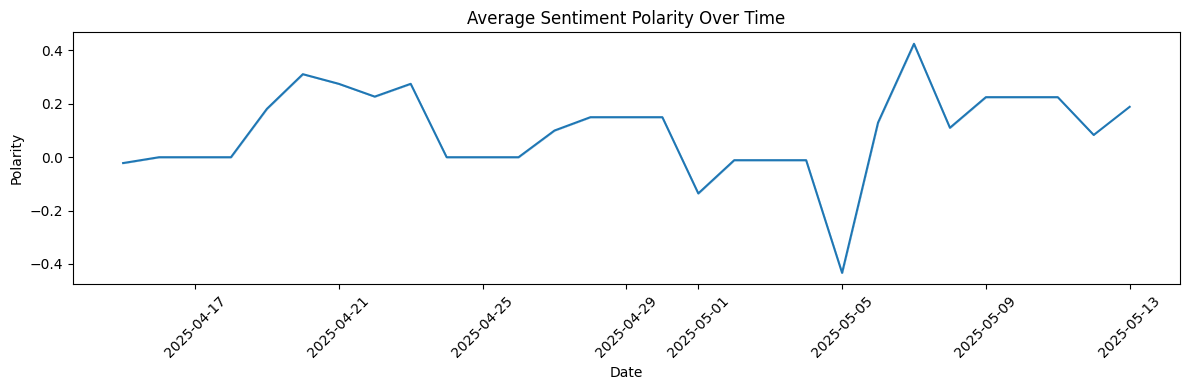

In [11]:
plot_sentiment_trends(aggregated_sentiment)


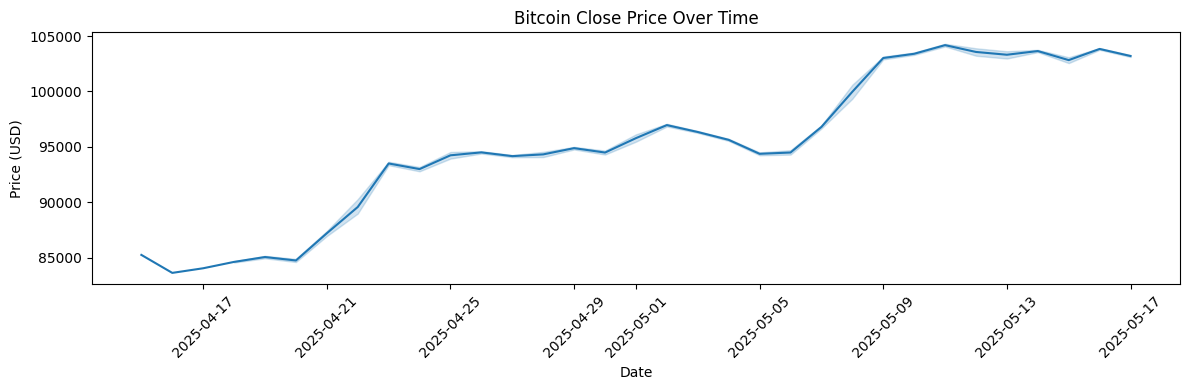

In [12]:
plot_price_trends(price_data)


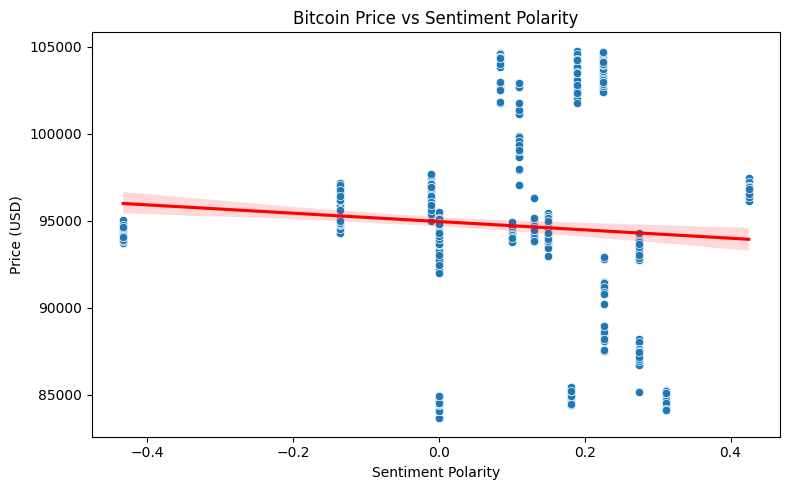

In [13]:
plot_price_vs_sentiment(merged_data)


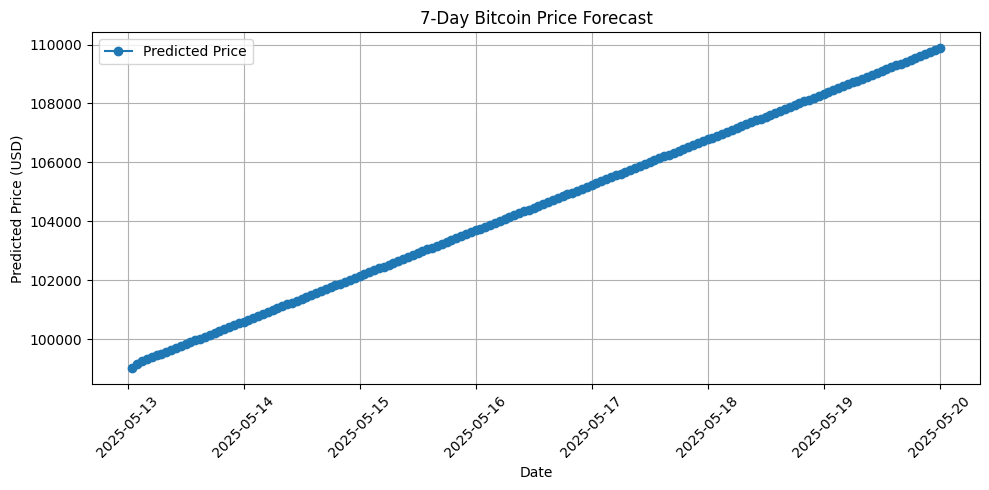

In [14]:
plot_future_forecast(future_forecast)  # if you're returning both results


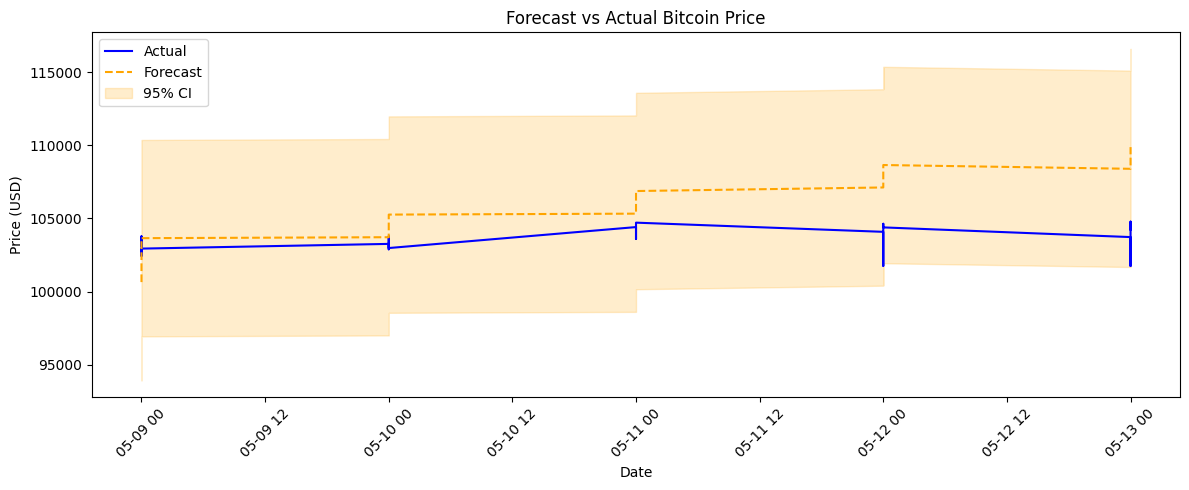

In [15]:
if forecast_results is not None:
    plot_forecast(forecast_results)



In [16]:
# === 6. Historical Comparison (Example) ===
comparison = compare_historical_sentiment(
    base_date=start_date_str,
    comparison_date=end_date_str,
    sentiment_df=aggregated_sentiment,
    price_df=price_data
)
print("\nHistorical Comparison:")
print(comparison)

2025-05-18 00:03:39 - src.utils_analyzer - WARNING - Missing data for comparison between 2025-04-19 and 2025-05-18

Historical Comparison:
None


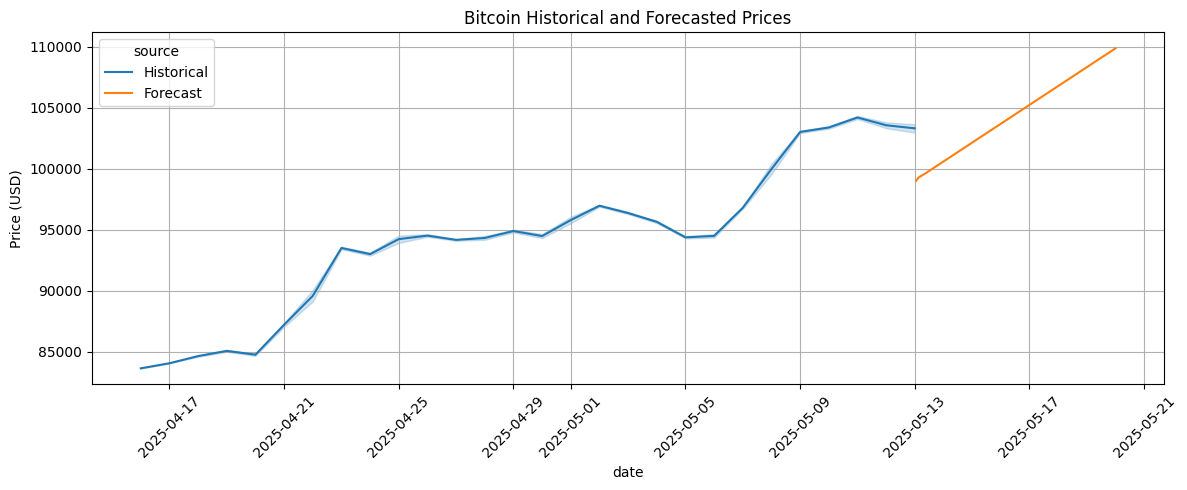

In [17]:
future = future_forecast.copy()
future['price'] = future['predicted_price']
future['source'] = 'Forecast'

historical = merged_data[['date', 'close_price']].copy()
historical['price'] = historical['close_price']
historical['source'] = 'Historical'

trend_df = pd.concat([historical[['date', 'price', 'source']], future[['date', 'price', 'source']]])

# plot it
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_df, x='date', y='price', hue='source')
plt.title('Bitcoin Historical and Forecasted Prices')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
trend_df

,date,price,source
24,2025-04-16 00:00:00,83641.904189,Historical
47,2025-04-16 00:00:00,83641.904189,Historical
61,2025-04-17 00:00:00,84058.847670,Historical
48,2025-04-17 00:00:00,84058.847670,Historical
456,2025-04-18 00:00:00,84946.916730,Historical
...,...,...,...
163,2025-05-19 20:00:00,109613.996261,Forecast
164,2025-05-19 21:00:00,109678.402565,Forecast
165,2025-05-19 22:00:00,109742.808868,Forecast
166,2025-05-19 23:00:00,109807.215171,Forecast


In [19]:
from src.models import run_auto_arima_forecast, run_lstm_forecast

# auto_arima_forecast = run_auto_arima_forecast(merged_data, forecast_hours=(24*7))
# lstm_forecast = run_lstm_forecast(merged_data, forecast_hours=(24*7), sequence_length=(24*7))


auto_arima_future, auto_arima_forecast = run_auto_arima_forecast(merged_data, forecast_hours=24*3)
lstm_future, lstm_forecast = run_lstm_forecast(merged_data, forecast_hours=24*3, sequence_length=24)

/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

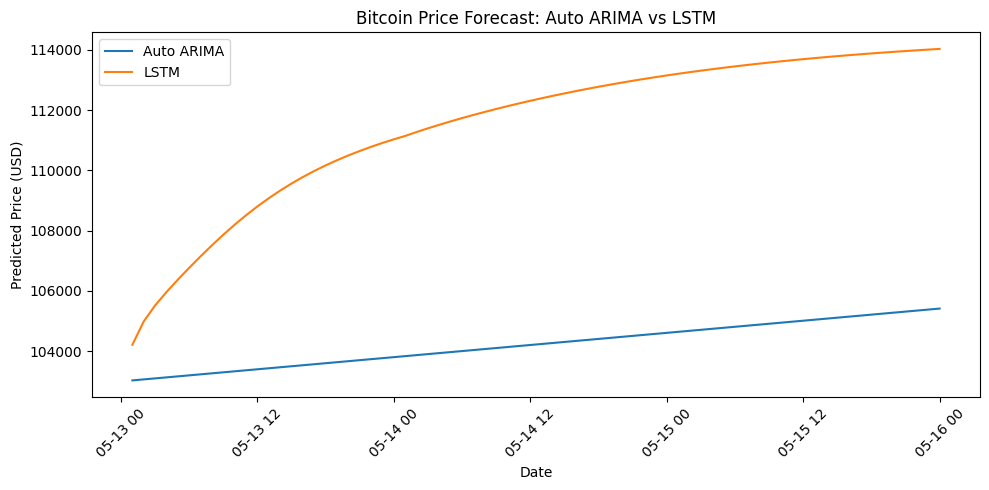

In [20]:
plt.figure(figsize=(10,5))
plt.plot(auto_arima_forecast['date'], auto_arima_forecast['predicted_price'], label='Auto ARIMA')
plt.plot(lstm_forecast['date'], lstm_forecast['predicted_price'], label='LSTM')
plt.legend()
plt.title('Bitcoin Price Forecast: Auto ARIMA vs LSTM')
plt.xlabel('Date')
plt.ylabel('Predicted Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

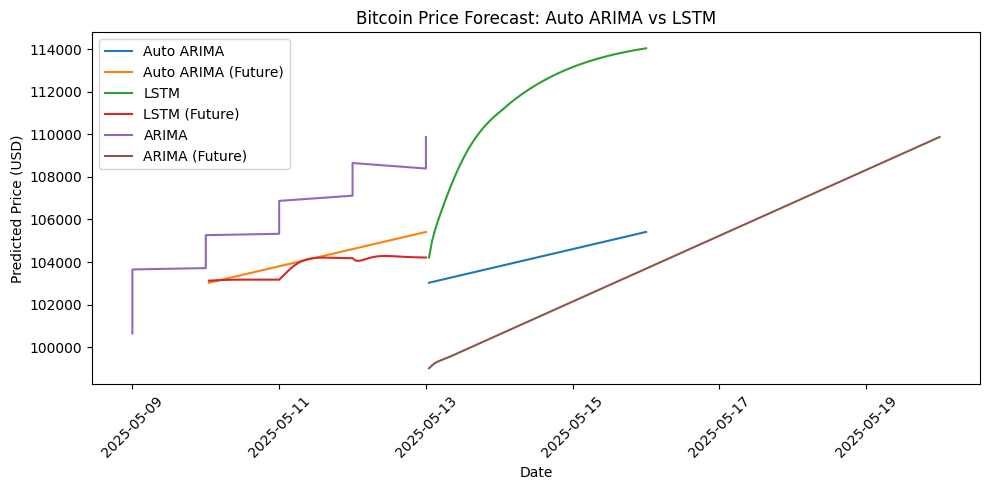

In [21]:
plt.figure(figsize=(10,5))
plt.plot(auto_arima_forecast['date'], auto_arima_forecast['predicted_price'], label='Auto ARIMA')
plt.plot(auto_arima_future['date'], auto_arima_future['predicted_price'], label='Auto ARIMA (Future)')
plt.plot(lstm_forecast['date'], lstm_forecast['predicted_price'], label='LSTM')
plt.plot(lstm_future['date'], lstm_future['predicted_price'], label='LSTM (Future)')
plt.plot(forecast_results['date'], forecast_results['predicted_price'], label='ARIMA')
plt.plot(future_forecast['date'], future_forecast['predicted_price'], label='ARIMA (Future)')
plt.legend()
plt.title('Bitcoin Price Forecast: Auto ARIMA vs LSTM')
plt.xlabel('Date')
plt.ylabel('Predicted Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

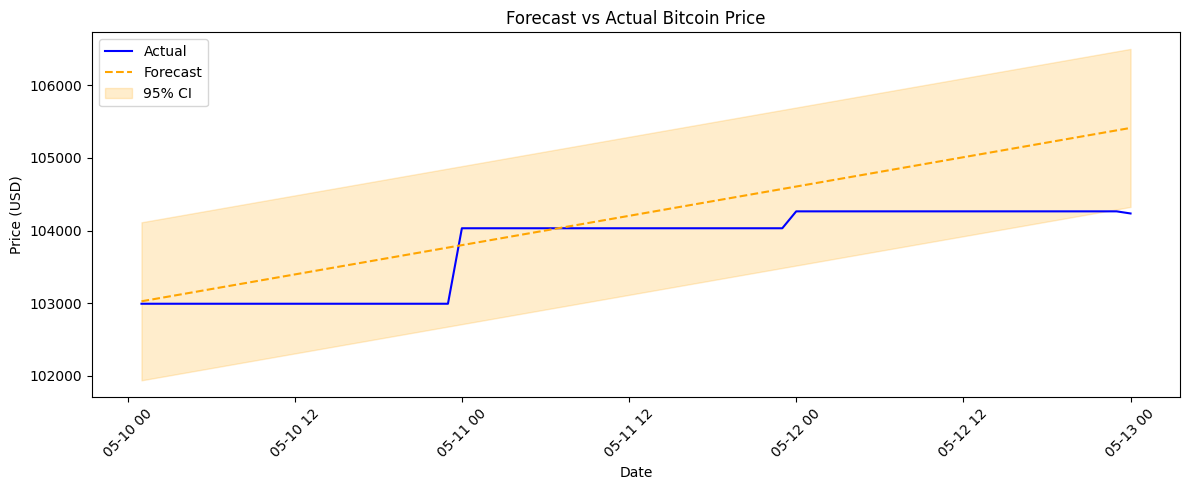

In [22]:
if auto_arima_forecast is not None:
    plot_forecast(auto_arima_future)

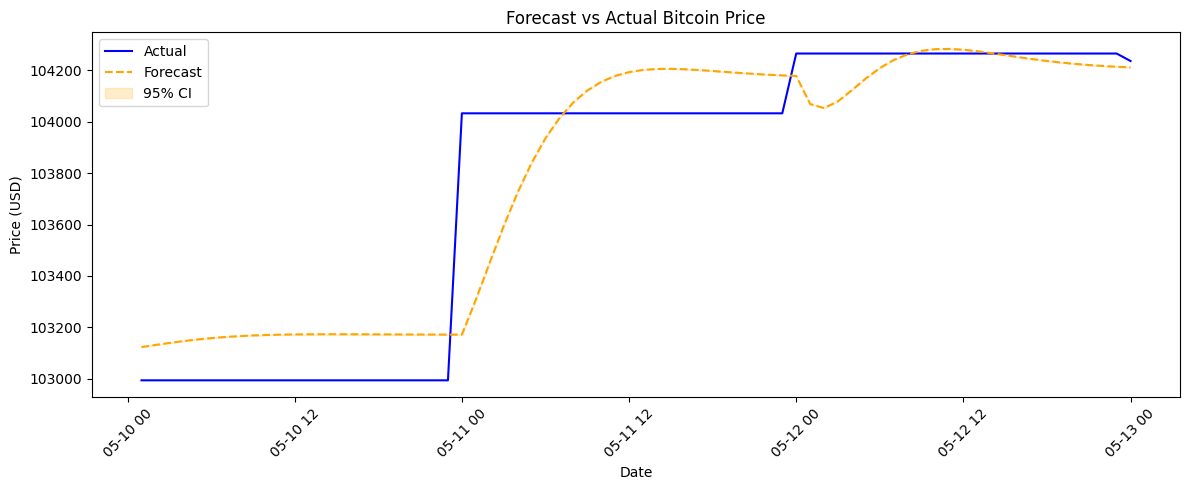

In [23]:
if lstm_future is not None:
    plot_forecast(lstm_future)

In [24]:
display(auto_arima_forecast)

,date,predicted_price
0,2025-05-13 01:00:00,103027.541153
1,2025-05-13 02:00:00,103061.138444
2,2025-05-13 03:00:00,103094.735735
3,2025-05-13 04:00:00,103128.333026
4,2025-05-13 05:00:00,103161.930317
...,...,...
67,2025-05-15 20:00:00,105278.559657
68,2025-05-15 21:00:00,105312.156948
69,2025-05-15 22:00:00,105345.754239
70,2025-05-15 23:00:00,105379.351530


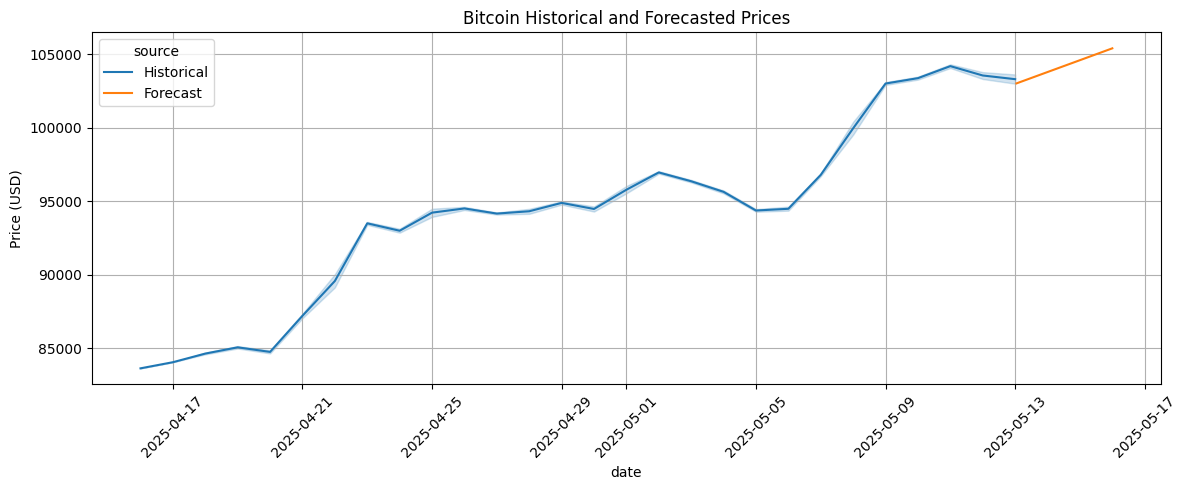

In [25]:
auto_arima_forecast_future = auto_arima_forecast.copy()
auto_arima_forecast_future['price'] = auto_arima_forecast_future['predicted_price']
auto_arima_forecast_future['source'] = 'Forecast'

auto_arima_forecast_historical = merged_data[['date', 'close_price']].copy()
auto_arima_forecast_historical['price'] = auto_arima_forecast_historical['close_price']
auto_arima_forecast_historical['source'] = 'Historical'

trend_df = pd.concat([auto_arima_forecast_historical[['date', 'price', 'source']], auto_arima_forecast_future[['date', 'price', 'source']]])

# plot it
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_df, x='date', y='price', hue='source')
plt.title('Bitcoin Historical and Forecasted Prices')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
display(lstm_forecast)

,date,predicted_price
0,2025-05-13 01:00:00,104211.269213
1,2025-05-13 02:00:00,104985.735381
2,2025-05-13 03:00:00,105517.486199
3,2025-05-13 04:00:00,105962.310276
4,2025-05-13 05:00:00,106373.010728
...,...,...
67,2025-05-15 20:00:00,113938.361112
68,2025-05-15 21:00:00,113963.857950
69,2025-05-15 22:00:00,113988.356648
70,2025-05-15 23:00:00,114011.911292


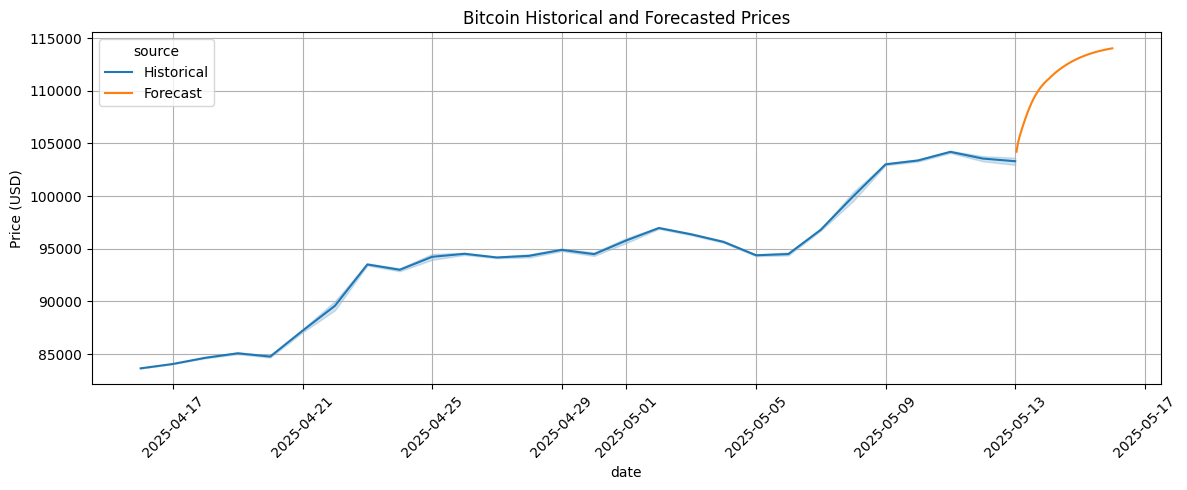

In [27]:
lstm_forecast_future = lstm_forecast.copy()
lstm_forecast_future['price'] = lstm_forecast_future['predicted_price']
lstm_forecast_future['source'] = 'Forecast'

lstm_forecast_historical = merged_data[['date', 'close_price']].copy()
lstm_forecast_historical['price'] = lstm_forecast_historical['close_price']
lstm_forecast_historical['source'] = 'Historical'

trend_df = pd.concat([lstm_forecast_historical[['date', 'price', 'source']], lstm_forecast_future[['date', 'price', 'source']]])

# plot it
plt.figure(figsize=(12, 5))

sns.lineplot(data=trend_df, x='date', y='price', hue='source')
plt.title('Bitcoin Historical and Forecasted Prices')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()